# Nicheformer vs PCA for Spatial Perturbation Prediction

**Question**: Do Nicheformer cell embeddings (from `model.get_embeddings()`) improve
perturbation response prediction over the linear PCA baseline?

**Comparison**: Both use the same bilinear ridge regression frame:
$$Y = A \times K \times B + \text{center} + \text{baseline}$$

| Method | A (gene embeddings) | B (condition embeddings) |
|--------|---------------------|--------------------------|
| PCA baseline | SVD on $Y_{change}$ | SVD on $Y_{change}$ |
| Nicheformer | SVD on $Y_{change}$ | `model.get_embeddings()` pseudobulked per condition |

**Pipeline** (following `nicheformer_pipeline_example.ipynb`):
1. h5 → h5ad conversion
2. `preprocess_spatial.py` (gene mapping mouse→Ensembl, reorder to model.h5ad, token-ID encoding)
3. `NicheformerDataset` + `model.get_embeddings()` → cell embeddings
4. Pseudobulk per condition → condition embeddings → bilinear model

**Data**: CosMx **mouse** liver perturbation map (GEO), 6363 cells, 1053 genes,
6 conditions (None=ctrl, KP, periphery, Tgfbr2, Ifngr2, Jak2)

In [3]:
import os, sys, json, subprocess
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/root/code/nicheformer/output/0518')
from evaluate import evaluate
sys.path.insert(0, '/root/code/nicheformer/src')

print('Imports OK')

Global seed set to 0


Imports OK


In [4]:
# ============================================================================
# Paths
# ============================================================================
PERTURB_H5       = '/mnt/172/wh/25-12/spatial/raw/pertubmap/perturb_map_data_all.h5'
PERTURB_H5AD     = '/mnt/172/wh/25-12/spatial/raw/pertubmap/perturb_map_adata.h5ad'
CHECKPOINT       = '/mnt/172/wh/25-12/nicheformer/ckpt/nicheformer.ckpt'
TECH_MEAN        = '/mnt/172/wh/25-12/nicheformer/data/model_means/visium_mean_script.npy'
CONFIG_YAML      = '/root/code/nicheformer/output/0518/preprocess_perturb_map_config.yaml'
CONVERT_SCRIPT   = '/root/code/nicheformer/output/0518/convert_perturb_h5_to_h5ad.py'
PREPROCESS_SCRIPT = '/root/code/nicheformer/output/0512_spatial/preprocess_spatial.py'
OUTPUT_DIR       = '/root/code/nicheformer/output/0518/nicheformer_evaluation_results'

os.makedirs(OUTPUT_DIR, exist_ok=True)

---
## 1. Convert h5 → h5ad

The perturbation map data is stored as raw h5 files (GEO format, mouse).
Convert to AnnData with proper `.obs` columns (perturbation, tissue, batch, x, y).

In [5]:
if not os.path.exists(PERTURB_H5AD):
    print('Running h5 → h5ad conversion ...')
    result = subprocess.run(
        ['uv', 'run', 'python', CONVERT_SCRIPT],
        capture_output=True, text=True, cwd=os.path.dirname(CONVERT_SCRIPT)
    )
    print(result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr[-1000:])
        raise RuntimeError('Conversion failed')
else:
    print(f'Already exists: {PERTURB_H5AD}')

adata_raw = sc.read_h5ad(PERTURB_H5AD)
print(f'Raw AnnData: {adata_raw.shape}')
print(f'obs columns: {list(adata_raw.obs.columns)}')
print(f'Perturbations: {sorted(adata_raw.obs["perturbation"].unique())}')
print(f'Batches: {sorted(adata_raw.obs["batch"].unique())}')

Already exists: /mnt/172/wh/25-12/spatial/raw/pertubmap/perturb_map_adata.h5ad
Raw AnnData: (6363, 1053)
obs columns: ['perturbation', 'tissue_type_raw', 'batch', 'x', 'y']
Perturbations: ['Ifngr2', 'Jak2', 'KP', 'None', 'Tgfbr2', 'periphery']
Batches: ['GSM5808054', 'GSM5808055', 'GSM5808056', 'GSM5808057']


---
## 2. Preprocess via `preprocess_spatial.py`

This handles the full preprocessing pipeline:
1. **Gene symbol → Ensembl ID** via mygene (`species='mouse'`)
2. **CELLxGENE validation**
3. **Gene reordering** via `ad.concat([model, adata], join='outer')` → matches model.h5ad gene order
4. **Technology mean** (cosmx_mean_script.npy)
5. **Token ID encoding** (assay=8 CosMx, specie=6 mouse, modality=4 spatial)

After this: gene column _i_ → Nicheformer token ID = _i_ + 30.

In [10]:
PREPROCESSED_DIR  = '/mnt/172/wh/25-12/spatial/preprocessed'
PREPROCESSED_NAME = 'visium_mouse_perturb_map.h5ad'
PREPROCESSED_PATH = os.path.join(PREPROCESSED_DIR, PREPROCESSED_NAME)
MODEL_H5AD_PATH = '/mnt/172/wh/25-12/nicheformer/data/model_means/model.h5ad'

if not os.path.exists(PREPROCESSED_PATH):
    print('Running preprocess_spatial.py ...')
    result = subprocess.run(
        ['uv', 'run', 'python', PREPROCESS_SCRIPT, '--config-yaml', CONFIG_YAML],
        capture_output=True, text=True, cwd='/root/code/nicheformer', timeout=600)
    lines = result.stdout.split('\n')
    for line in lines[-30:]: print(line)
    if result.returncode != 0:
        print('STDERR:', result.stderr[-2000:])
        raise RuntimeError('Preprocessing failed')

adata_pp = sc.read_h5ad(PREPROCESSED_PATH)
print(f'\nPreprocessed: {adata_pp.shape[0]} cells x {adata_pp.shape[1]} genes')

# ==== Gene harmonization: mouse ENSMUSG → human ENSG orthologs ====
import mygene
mg = mygene.MyGeneInfo()
ensmusg_ids = list(adata_pp.var_names)

# 1. Query ENSMUSG IDs → homologene → human NCBI gene ID
r = mg.querymany(ensmusg_ids, scopes='ensembl.gene', fields='homologene',
                 species='mouse', returnall=True, as_dataframe=False)
mouse_to_human_ncbi = {}
for res in r['out']:
    mus = res.get('query', '')
    hom = res.get('homologene', {})
    if hom and 'genes' in hom:
        for tax_id, gene_id in hom['genes']:
            if tax_id == 9606: mouse_to_human_ncbi[mus] = str(gene_id); break

# 2. Human NCBI Gene IDs → ENSG
human_ids = list(set(mouse_to_human_ncbi.values()))
human_to_ensg = {}
for i in range(0, len(human_ids), 1000):
    r2 = mg.querymany(human_ids[i:i+1000], scopes='entrezgene', fields='ensembl.gene',
                      species='human', returnall=True, as_dataframe=False)
    for res in r2['out']:
        ens = res.get('ensembl', {})
        if isinstance(ens, dict): ensg = ens.get('gene', '')
        elif isinstance(ens, list): ensg = ens[0].get('gene', '') if ens else ''
        else: ensg = ''
        if ensg: human_to_ensg[res.get('query', '')] = ensg

# 3. Build ENSMUSG → ENSG + dedup (sum counts for duplicate orthologs)
mus_to_ensg = {}
for mus_id, ncbi in mouse_to_human_ncbi.items():
    ensg = human_to_ensg.get(ncbi, '')
    if ensg: mus_to_ensg[mus_id] = ensg

new_var_names = []
for old_name in adata_pp.var_names:
    ensg = mus_to_ensg.get(old_name, '')
    new_var_names.append(ensg if ensg else old_name)

from collections import defaultdict
name_to_cols = defaultdict(list)
for i, name in enumerate(new_var_names): name_to_cols[name].append(i)

unique_names, agg_expr = [], []
X_dense = adata_pp.X.toarray() if sparse.issparse(adata_pp.X) else adata_pp.X
for name, col_indices in name_to_cols.items():
    agg_expr.append(X_dense[:, col_indices].sum(axis=1))
    unique_names.append(name)

adata_pp = sc.AnnData(
    X=sparse.csr_matrix(np.column_stack(agg_expr), dtype=np.float32),
    obs=adata_pp.obs.copy(), var=pd.DataFrame(index=unique_names))
n_mapped = sum(1 for n in unique_names if n.startswith('ENSG'))
print(f'Ortholog-mapped: {n_mapped} genes, dedup: {len(new_var_names)}→{len(unique_names)}')

# ==== Gene reordering ====
model_ref = sc.read_h5ad(MODEL_H5AD_PATH)
overlap = set(adata_pp.var_names) & set(model_ref.var_names)
print(f'Overlap with model.h5ad: {len(overlap)} genes ({len(overlap)/adata_pp.shape[1]*100:.0f}%)')

adata_pp = ad.concat([model_ref, adata_pp], join='outer', axis=0)
adata_pp = adata_pp[1:].copy()
print(f'After gene reorder: {adata_pp.shape}')

# ==== Compute custom Visium technology mean from this data ====
# Per-gene nonzero mean across all perturbation spots, following the same
# recipe as preprocess_spatial.py: nan_to_num → round → zeros→1
TECH_MEAN_CUSTOM = os.path.join(OUTPUT_DIR, 'visium_perturb_mean.npy')

# Subset to model genes (first 20310) for tech mean computation
X_for_mean = adata_pp.X[:, :20310].toarray() if sparse.issparse(adata_pp.X) else adata_pp.X[:, :20310]
visium_mean = np.nan_to_num(X_for_mean).mean(axis=0)
visium_mean = np.where(visium_mean == 0, 1,
              np.where((visium_mean % 1) >= 0.5, np.ceil(visium_mean), np.floor(visium_mean)))
np.save(TECH_MEAN_CUSTOM, visium_mean)
print(f'Custom visium mean saved: {TECH_MEAN_CUSTOM}  shape={visium_mean.shape}')

# Context-token encoding
adata_pp.obs['assay'] = 9; adata_pp.obs['specie'] = 6
adata_pp.obs['modality'] = 4; adata_pp.obs['nicheformer_split'] = 'train'
print(f'context: assay=9(Visi), specie=6(mouse), modality=4(spatial)')


Preprocessed: 6363 cells x 1028 genes
Ortholog-mapped: 923 genes, dedup: 1028→1023
Overlap with model.h5ad: 903 genes (88%)
After gene reorder: (6363, 20430)
Custom visium mean saved: /root/code/nicheformer/output/0518/nicheformer_evaluation_results/visium_perturb_mean.npy  shape=(20310,)
context: assay=9(Visi), specie=6(mouse), modality=4(spatial)


In [ ]:
import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from nicheformer.models._nicheformer import Nicheformer
from nicheformer.data.dataset import NicheformerDataset

# Fix torch 2.6 default weights_only=True for checkpoint loading
import lightning_fabric.utilities.cloud_io as _cloud_io
_orig_load = _cloud_io._load
def _patched_load(path_or_url, map_location=None):
    fs = _cloud_io.get_filesystem(path_or_url)
    with fs.open(path_or_url, "rb") as f:
        return torch.load(f, map_location=map_location, weights_only=False)
_cloud_io._load = _patched_load

pl.seed_everything(42)
print(f'CUDA: {torch.cuda.is_available()}')

# Load technology mean — must match gene order in adata_pp
technology_mean = np.load(TECH_MEAN)
print(f'tech_mean: {technology_mean.shape}, adata genes: {adata_pp.shape[1]}')

# Safety: if adata_pp has extra genes not in model.h5ad, subset to model genes
if adata_pp.shape[1] != len(technology_mean):
    print(f'Gene mismatch — subsetting to model genes ({len(technology_mean)})')
    adata_pp = adata_pp[:, :len(technology_mean)].copy()
    print(f'After subset: {adata_pp.shape}')

# Create dataset — tokenizes per batch internally
dataset = NicheformerDataset(
    adata=adata_pp,
    technology_mean=technology_mean,
    split='train',
    max_seq_len=1500,
    aux_tokens=30,
    chunk_size=1000,
    metadata_fields={'obs': ['modality', 'specie', 'assay']}
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=False,
                        num_workers=4, pin_memory=True)
print(f'Dataset: {len(dataset)} cells, {len(dataloader)} batches')

Global seed set to 42


CUDA: True
tech_mean: (20310,), adata genes: 20430
Gene mismatch — subsetting to model genes (20310)
After subset: (6363, 20310)


100%|██████████| 7/7 [00:08<00:00,  1.23s/it]

Dataset: 6363 cells, 199 batches


In [13]:
import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from nicheformer.models._nicheformer import Nicheformer
from nicheformer.data.dataset import NicheformerDataset

# Fix torch 2.6 default weights_only=True for checkpoint loading
import lightning_fabric.utilities.cloud_io as _cloud_io
_orig_load = _cloud_io._load
def _patched_load(path_or_url, map_location=None):
    fs = _cloud_io.get_filesystem(path_or_url)
    with fs.open(path_or_url, "rb") as f:
        return torch.load(f, map_location=map_location, weights_only=False)
_cloud_io._load = _patched_load

pl.seed_everything(42)
print(f'CUDA: {torch.cuda.is_available()}')

# Use custom visium mean computed from this dataset
technology_mean = np.load(TECH_MEAN_CUSTOM)
print(f'tech_mean: {technology_mean.shape}, adata genes: {adata_pp.shape[1]}')

# Subset to model genes for tokenization (tech_mean always has 20310 entries)
if adata_pp.shape[1] != len(technology_mean):
    print(f'Gene mismatch — subsetting to model genes ({len(technology_mean)})')
    adata_pp = adata_pp[:, :len(technology_mean)].copy()
    print(f'After subset: {adata_pp.shape}')

dataset = NicheformerDataset(
    adata=adata_pp,
    technology_mean=technology_mean,
    split='train',
    max_seq_len=1500,
    aux_tokens=30,
    chunk_size=1000,
    metadata_fields={'obs': ['modality', 'specie', 'assay']}
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=False,
                        num_workers=4, pin_memory=True)
print(f'Dataset: {len(dataset)} cells, {len(dataloader)} batches')

Global seed set to 42


CUDA: True
tech_mean: (20310,), adata genes: 20310


100%|██████████| 7/7 [00:04<00:00,  1.42it/s]

Dataset: 6363 cells, 199 batches


In [14]:
# Load model & extract embeddings
import os
from tqdm import tqdm
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
model = Nicheformer.load_from_checkpoint(CHECKPOINT, strict=False, weights_only=False)
model.eval()
device = 'cuda'
model = model.to(device)
cell_embeddings = []
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Embedding"):
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()}
        emb = model.get_embeddings(batch=batch, layer=-1, with_context=False)
        cell_embeddings.append(emb.cpu().numpy())

cell_embeddings = np.concatenate(cell_embeddings, axis=0)
print(f'Cell embeddings: {cell_embeddings.shape}')

Embedding: 100%|██████████| 199/199 [01:12<00:00,  2.73it/s]

Cell embeddings: (6363, 512)


---
## 4. Pseudobulk & Setup Y Matrix

Aggregate expression and cell embeddings by perturbation type.

In [15]:
perturbation = adata_pp.obs['perturbation'].values
pert_types = np.unique(perturbation)
X_pp = adata_pp.X.toarray() if sparse.issparse(adata_pp.X) else adata_pp.X

pseudobulk_expr = []
pseudobulk_labels = []
condition_emb = {}  # mean cell embedding per condition

for p in pert_types:
    mask = perturbation == p
    if mask.sum() == 0:
        continue
    pseudobulk_expr.append(X_pp[mask].sum(axis=0))
    pseudobulk_labels.append(p)
    condition_emb[p] = cell_embeddings[mask].mean(axis=0)

pseudobulk_expr = np.array(pseudobulk_expr)      # (n_conditions, n_genes)
pseudobulk_labels = np.array(pseudobulk_labels)

Y_raw = pseudobulk_expr.T  # (n_genes, n_conditions)
print(f'Y_raw: {Y_raw.shape} (genes × conditions)')
print(f'Conditions: {list(pseudobulk_labels)}')

# Nicheformer condition embedding matrix: (512, n_conditions)
B_niche_raw = np.array([condition_emb[p] for p in pseudobulk_labels]).T
print(f'B_niche_raw: {B_niche_raw.shape}')

Y_raw: (20310, 6) (genes × conditions)
Conditions: ['Ifngr2', 'Jak2', 'KP', 'None', 'Tgfbr2', 'periphery']
B_niche_raw: (512, 6)


In [16]:
# Baseline = control (None) expression
ctrl_idx = np.where(pseudobulk_labels == 'None')[0][0]
baseline = Y_raw[:, ctrl_idx]
Y_change = Y_raw - baseline[:, np.newaxis]

# Filter to genes with ANY expression across conditions (not just control)
expressed_mask = (pseudobulk_expr.sum(axis=0) > 0)  # gene expressed in ≥1 condition
n_expressed = expressed_mask.sum()
print(f'Expressed genes: {n_expressed} / {len(baseline)}')

Y_raw = Y_raw[expressed_mask, :]
Y_change = Y_change[expressed_mask, :]
baseline = baseline[expressed_mask]
print(f'After filtering: Y_raw={Y_raw.shape}, Y_change={Y_change.shape}')

Expressed genes: 985 / 20310
After filtering: Y_raw=(985, 6), Y_change=(985, 6)


In [17]:
# count nonzero genes in each condition
for i, label in enumerate(pseudobulk_labels):
    print(f'{label}: {(pseudobulk_expr[i, :] > 0).sum()} nonzero genes')

# count nonzero genes in any condition
print(f'Any condition: {(pseudobulk_expr > 0).sum()} nonzero genes')

Ifngr2: 974 nonzero genes
Jak2: 848 nonzero genes
KP: 985 nonzero genes
None: 985 nonzero genes
Tgfbr2: 981 nonzero genes
periphery: 985 nonzero genes
Any condition: 5758 nonzero genes


In [33]:
Y_change

array([[-6217., -6388., -5944.,     0., -6221., -5818.],
       [-4311., -4336., -3869.,     0., -4273., -3839.],
       [ -816.,  -816.,  -759.,     0.,  -816.,  -791.],
       ...,
       [-6175., -6219., -3189.,     0., -5778., -5030.],
       [ -871.,  -878.,  -671.,     0.,  -848.,  -740.],
       [ -310.,  -323.,   249.,     0.,  -176.,  -137.]])

---
## 5. PCA Baseline: $A_{pca}$ and $B_{pca}$ via SVD

In [18]:
def compute_pca_embeddings(Y_change, pca_dim=5):
    Y_centered = Y_change - Y_change.mean(axis=1, keepdims=True)
    U, s, Vt = np.linalg.svd(Y_centered, full_matrices=False)
    dim = min(pca_dim, len(s))
    return U[:, :dim] * s[:dim], Vt[:dim, :]

def solve_bilinear(Y_change, A, B, ridge_penalty=0.1):
    center = Y_change.mean(axis=1)
    Y_c = Y_change - center[:, np.newaxis]
    n_dim = A.shape[1]
    ATA_reg = A.T @ A + np.eye(n_dim) * ridge_penalty
    left = np.linalg.solve(ATA_reg, A.T)
    BBT_reg = B @ B.T + np.eye(n_dim) * ridge_penalty
    right = Y_c @ B.T @ np.linalg.solve(BBT_reg, np.eye(n_dim))
    K = left @ right
    K[np.isnan(K)] = 0
    return K, center, A @ K @ B + center[:, np.newaxis]

pca_dim = min(5, len(pert_types) - 1)
A_pca, B_pca = compute_pca_embeddings(Y_change, pca_dim=pca_dim)
print(f'A_pca: {A_pca.shape}, B_pca: {B_pca.shape}')

A_pca: (985, 5), B_pca: (5, 6)


---
## 6. Nicheformer Condition Embeddings $B_{niche}$

Pseudobulked cell embeddings → PCA-reduced to match baseline dimension.

In [19]:
def reduce_dim_rows(X, target_dim):
    """PCA-reduce rows of X from (d, n) → (target_dim, n)."""
    if X.shape[0] <= target_dim:
        return X
    X_c = X - X.mean(axis=1, keepdims=True)
    U, s, Vt = np.linalg.svd(X_c, full_matrices=False)
    return s[:target_dim, None] * Vt[:target_dim, :]

# Standardize Nicheformer condition embeddings
scaler_niche = StandardScaler()
B_niche_std = scaler_niche.fit_transform(B_niche_raw.T).T  # (512, 6)

# Match PCA dimension for fair comparison
B_niche = reduce_dim_rows(B_niche_std, pca_dim)  # (5, 6)
print(f'B_niche: {B_niche.shape}')

B_niche: (5, 6)


---
## 7. Regularization Sweep (LOCO-CV)

Leave-one-condition-out CV. For Nicheformer, sweep both ridge $\lambda$ and embedding dimension.

In [37]:
def loco_cv(Y_change, Y_raw, baseline, labels, ridge_penalty, B_niche_full=None):
    """
    Leave-one-condition-out CV with per-fold A recomputation.
    A is recomputed from training Y_change only (prevents leakage through gene PCs).
    B: for PCA, recomputed per fold; for Nicheformer, from cell embeddings (no Y leakage).
    """
    non_ctrl_idx = np.where(labels != 'None')[0]
    ctrl_j = np.where(labels == 'None')[0][0]
    max_dim = min(len(non_ctrl_idx), Y_change.shape[0])

    maes, pearsons = [], []
    for held_out in non_ctrl_idx:
        train_idx = [ctrl_j] + [j for j in range(len(labels))
                                if j != held_out and labels[j] != 'None']
        Yt = Y_change[:, train_idx]

        if B_niche_full is not None:
            # Nicheformer: A from training Y, B from cell embeddings (independent)
            A_train, _ = compute_pca_embeddings(Yt, pca_dim=max_dim)
            B_train_full = B_niche_full[:, train_idx]          # (512, n_train)
            B_train = reduce_dim_rows(B_train_full, max_dim)   # (max_dim, n_train)
            # Held-out B: reduce full B to max_dim, take held-out column
            B_held = reduce_dim_rows(B_niche_full, max_dim)[:, held_out:held_out+1]
        else:
            # PCA: recompute both A and B from training Y only
            A_train, B_train_full = compute_pca_embeddings(Yt, pca_dim=max_dim)
            B_train = B_train_full
            # Held-out B: solve Y_held ≈ A_train @ K @ B_held → B_held = K⁻¹ A⁻¹ Y_held
            # Simpler: project held-out expression onto A_train's column space
            ATA_reg = A_train.T @ A_train + np.eye(max_dim) * 1e-6
            B_held = np.linalg.solve(ATA_reg, A_train.T) @ Y_change[:, held_out:held_out+1]

        K, center, _ = solve_bilinear(Yt, A_train, B_train, ridge_penalty)
        pred = (A_train @ K @ B_held + center[:, np.newaxis]
                + baseline[:, np.newaxis]).flatten()
        true = Y_raw[:, held_out]

        maes.append(np.mean(np.abs(pred - true)))
        pc, tc = pred - pred.mean(), true - true.mean()
        denom = np.linalg.norm(pc) * np.linalg.norm(tc)
        pearsons.append(np.dot(pc, tc) / denom if denom > 0 else 0.0)

    return (np.mean(maes), np.std(maes), np.mean(pearsons), np.std(pearsons))

lambda_values = np.logspace(-2, 4, 13)
print(f'Lambda sweep: {len(lambda_values)} values [{lambda_values[0]:.2e}, {lambda_values[-1]:.0f}]')

Lambda sweep: 13 values [1.00e-02, 10000]


In [38]:
# ---- PCA Baseline ----
print('PCA Baseline (A and B recomputed per fold from training Y only)')
pca_results = []
for lam in lambda_values:
    mae, mae_s, r, r_s = loco_cv(
        Y_change, Y_raw, baseline, pseudobulk_labels, lam, B_niche_full=None)
    pca_results.append({'lambda': lam, 'MAE': mae, 'MAE_std': mae_s,
                        'Pearson_r': r, 'Pearson_std': r_s,
                        'method': 'PCA', 'dim': 5})

pca_df = pd.DataFrame(pca_results)
best_pca = pca_df.loc[pca_df['MAE'].idxmin()]
print(f"Best: lambda={best_pca['lambda']:.4f}, MAE={best_pca['MAE']:.1f}, r={best_pca['Pearson_r']:.4f}")

PCA Baseline (A and B recomputed per fold from training Y only)
Best: lambda=3.1623, MAE=641.8, r=0.7602


In [39]:
# ---- Nicheformer: sweep lambda ----
# B_niche from cell embeddings is independent of Y (no leakage).
# A is recomputed per fold from training Y_change only.
print('Nicheformer (A=recomputed per fold, B=cell-embeddings)')
niche_all = []
for lam in lambda_values:
    mae, mae_s, r, r_s = loco_cv(
        Y_change, Y_raw, baseline, pseudobulk_labels, lam, B_niche_full=B_niche_std)
    niche_all.append({'lambda': lam, 'MAE': mae, 'MAE_std': mae_s,
                      'Pearson_r': r, 'Pearson_std': r_s,
                      'method': 'Nicheformer', 'dim': 5})

niche_df = pd.DataFrame(niche_all)
best_niche = niche_df.loc[niche_df['MAE'].idxmin()]
print(f"Best: lambda={best_niche['lambda']:.4f}, MAE={best_niche['MAE']:.1f}, r={best_niche['Pearson_r']:.4f}")

Nicheformer (A=recomputed per fold, B=cell-embeddings)
Best: lambda=10000.0000, MAE=1929.5, r=0.5448


---
## 8. Visualize Sweep Results

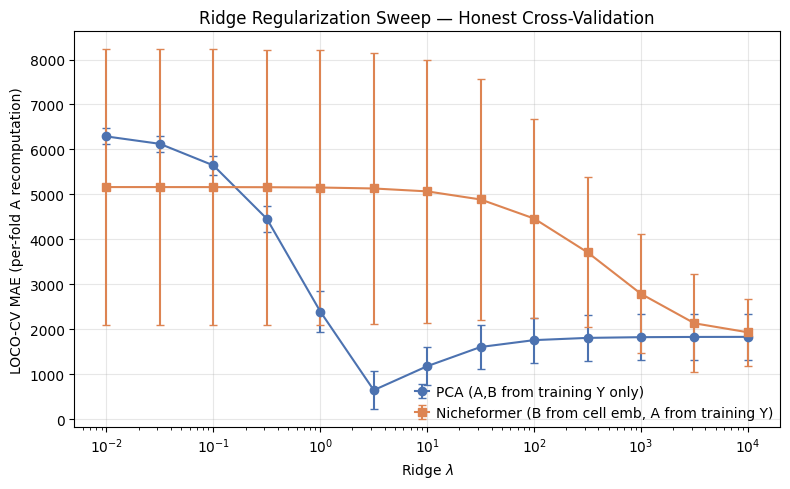

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(pca_df['lambda'], pca_df['MAE'], yerr=pca_df['MAE_std'],
            marker='o', label='PCA (A,B from training Y only)', capsize=3, color='#4C72B0')
ax.errorbar(niche_df['lambda'], niche_df['MAE'], yerr=niche_df['MAE_std'],
            marker='s', label='Nicheformer (B from cell emb, A from training Y)', capsize=3, color='#DD8452')
ax.set_xscale('log'); ax.set_xlabel('Ridge $\\lambda$')
ax.set_ylabel('LOCO-CV MAE (per-fold A recomputation)')
ax.set_title('Ridge Regularization Sweep — Honest Cross-Validation')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'regularization_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Final Evaluation with `evaluate.py`

Fit best models on ALL data, then evaluate per-condition with pertpy-based metrics.

In [41]:
# Fit best models — for final evaluation (note: this is training fit, LOCO-CV is the honest metric)
best_pca_l = best_pca['lambda']
_, _, Y_pred_pca_c = solve_bilinear(Y_change, A_pca, B_pca, ridge_penalty=best_pca_l)
Y_pred_pca = Y_pred_pca_c + baseline[:, np.newaxis]

best_niche_l = best_niche['lambda']
B_niche_final = reduce_dim_rows(B_niche_std, pca_dim)
_, _, Y_pred_niche_c = solve_bilinear(Y_change, A_pca, B_niche_final, ridge_penalty=best_niche_l)
Y_pred_niche = Y_pred_niche_c + baseline[:, np.newaxis]

print(f'PCA:        lambda={best_pca_l:.4f}')
print(f'Nicheformer: lambda={best_niche_l:.4f}')
print(f'(LOCO-CV is the honest evaluation; this fit uses all data, expect lower error)')

PCA:        lambda=3.1623
Nicheformer: lambda=10000.0000
(LOCO-CV is the honest evaluation; this fit uses all data, expect lower error)


In [32]:
Y_pred_niche.shape

(985, 6)

In [42]:
# Evaluate per condition — use only expressed genes to avoid NaN from all-zero rows
pert_labels_raw = adata_pp.obs['perturbation'].values
X_full = adata_pp.X.toarray() if sparse.issparse(adata_pp.X) else adata_pp.X
X_eval = X_full[:, expressed_mask]  # subset to expressed genes only
eval_genes = [g for g, m in zip(adata_pp.var_names, expressed_mask) if m]
ctrl_mask = pert_labels_raw == 'None'
ctrl_expr = X_eval[ctrl_mask]

print(f'X_eval: {X_eval.shape}, genes: {len(eval_genes)}')

all_eval = []

for ci, cond in enumerate(pseudobulk_labels):
    if cond == 'None':
        continue
    cond_mask = pert_labels_raw == cond
    n = cond_mask.sum()
    stim = X_eval[cond_mask]

    true_adata = sc.AnnData(
        X=sparse.csr_matrix(stim),
        obs=pd.DataFrame({'perturbation': [cond] * n}),
        var=pd.DataFrame(index=eval_genes)
    )
    true_adata.layers['logNor'] = stim.copy()
    sc.pp.normalize_total(true_adata, target_sum=1e4)
    sc.pp.log1p(true_adata)
    true_adata.layers['logNor'] = (true_adata.X.toarray()
        if sparse.issparse(true_adata.X) else true_adata.X.copy())
    true_adata.X = sparse.csr_matrix(stim)

    for method, Y_pred in [('PCA', Y_pred_pca), ('Nicheformer', Y_pred_niche)]:
        pred = np.tile(Y_pred[:, ci], (n, 1))
        save_dir = os.path.join(OUTPUT_DIR, method.lower(), cond)
        try:
            df = evaluate(pred_expr=pred, true_expr=true_adata, ctrl_expr=ctrl_expr,
                          gene_names=eval_genes, condition_col='perturbation',
                          save_dir=save_dir, top_n=100, de_method='wilcoxon', subsample_n=2000)
            df.insert(0, 'condition', cond)
            df.insert(0, 'method', method)
            all_eval.append(df)
        except Exception as e:
            print(f'[ERROR] {method} {cond}: {e}')

print(f'Collected {len(all_eval)} evaluation results')

X_eval: (6363, 985), genes: 985
Shapes for vstack -> Ctrl:(4357, 985), Stim:(105, 985), Pred:(105, 985)
[WARN top] mse failed for Ifngr2: None
[WARN top] pearson_distance failed for Ifngr2: None


Output()

[WARN top] wasserstein failed for Ifngr2: None
[WARN top] sym_kldiv failed for Ifngr2: Metric sym_kldiv not recognized.
Saved evaluation at: /root/code/nicheformer/output/0518/nicheformer_evaluation_results/pca/Ifngr2
   mse_all_Ifngr2  pearson_distance_all_Ifngr2  edistance_all_Ifngr2  \
0          0.8191                       0.2672               28.4046   

   wasserstein_all_Ifngr2  sym_kldiv_all_Ifngr2  mse_all  \
0                 28.4046          1.103197e+16   0.8191   

   pearson_distance_all  edistance_all  wasserstein_all  sym_kldiv_all  \
0                0.2672        28.4046          28.4046   1.103197e+16   

   mse_top100_Ifngr2  pearson_distance_top100_Ifngr2  edistance_top100_Ifngr2  \
0                NaN                             NaN                  13.4613   

   wasserstein_top100_Ifngr2  sym_kldiv_top100_Ifngr2  \
0                        NaN                      NaN   

   common_degs_top100_Ifngr2  
0                          7  
Shapes for vstack -> Ctrl:(

Output()

[WARN top] wasserstein failed for Ifngr2: None
[WARN top] sym_kldiv failed for Ifngr2: Metric sym_kldiv not recognized.
Saved evaluation at: /root/code/nicheformer/output/0518/nicheformer_evaluation_results/nicheformer/Ifngr2
   mse_all_Ifngr2  pearson_distance_all_Ifngr2  edistance_all_Ifngr2  \
0          0.8265                       0.2709               28.5318   

   wasserstein_all_Ifngr2  sym_kldiv_all_Ifngr2  mse_all  \
0                 28.5318          1.106887e+16   0.8265   

   pearson_distance_all  edistance_all  wasserstein_all  sym_kldiv_all  \
0                0.2709        28.5318          28.5318   1.106887e+16   

   mse_top100_Ifngr2  pearson_distance_top100_Ifngr2  edistance_top100_Ifngr2  \
0                NaN                             NaN                  13.6809   

   wasserstein_top100_Ifngr2  sym_kldiv_top100_Ifngr2  \
0                        NaN                      NaN   

   common_degs_top100_Ifngr2  
0                          8  
Shapes for vstack -

...

[WARN top] wasserstein failed for Tgfbr2: None
[WARN top] sym_kldiv failed for Tgfbr2: Metric sym_kldiv not recognized.
Saved evaluation at: /root/code/nicheformer/output/0518/nicheformer_evaluation_results/nicheformer/Tgfbr2
   mse_all_Tgfbr2  pearson_distance_all_Tgfbr2  edistance_all_Tgfbr2  \
0          0.7946                       0.2466                27.977   

   wasserstein_all_Tgfbr2  sym_kldiv_all_Tgfbr2  mse_all  \
0                  27.977          1.072347e+16   0.7946   

   pearson_distance_all  edistance_all  wasserstein_all  sym_kldiv_all  \
0                0.2466         27.977           27.977   1.072347e+16   

   mse_top100_Tgfbr2  pearson_distance_top100_Tgfbr2  edistance_top100_Tgfbr2  \
0                NaN                             NaN                  13.5543   

   wasserstein_top100_Tgfbr2  sym_kldiv_top100_Tgfbr2  \
0                        NaN                      NaN   

   common_degs_top100_Tgfbr2  
0                          3  
Shapes for vstack -

Output()

[WARN top] wasserstein failed for periphery: None
[WARN top] sym_kldiv failed for periphery: Metric sym_kldiv not recognized.
Saved evaluation at: /root/code/nicheformer/output/0518/nicheformer_evaluation_results/pca/periphery
   mse_all_periphery  pearson_distance_all_periphery  edistance_all_periphery  \
0             0.1014                          0.0402                   9.9918   

   wasserstein_all_periphery  sym_kldiv_all_periphery  mse_all  \
0                     9.9918             8.412598e+15   0.1014   

   pearson_distance_all  edistance_all  wasserstein_all  sym_kldiv_all  \
0                0.0402         9.9918           9.9918   8.412598e+15   

   mse_top100_periphery  pearson_distance_top100_periphery  \
0                   NaN                                NaN   

   edistance_top100_periphery  wasserstein_top100_periphery  \
0                      7.4126                           NaN   

   sym_kldiv_top100_periphery  common_degs_top100_periphery  
0             

Output()

[WARN top] wasserstein failed for periphery: None
[WARN top] sym_kldiv failed for periphery: Metric sym_kldiv not recognized.
Saved evaluation at: /root/code/nicheformer/output/0518/nicheformer_evaluation_results/nicheformer/periphery
   mse_all_periphery  pearson_distance_all_periphery  edistance_all_periphery  \
0             0.1058                          0.0432                  10.2076   

   wasserstein_all_periphery  sym_kldiv_all_periphery  mse_all  \
0                    10.2076             8.434723e+15   0.1058   

   pearson_distance_all  edistance_all  wasserstein_all  sym_kldiv_all  \
0                0.0432        10.2076          10.2076   8.434723e+15   

   mse_top100_periphery  pearson_distance_top100_periphery  \
0                   NaN                                NaN   

   edistance_top100_periphery  wasserstein_top100_periphery  \
0                      7.4898                           NaN   

   sym_kldiv_top100_periphery  common_degs_top100_periphery  
0     

---
## 10. Results Summary

In [43]:
if all_eval:
    combined = pd.concat(all_eval, ignore_index=True)
    metric_cols = [c for c in combined.columns if c not in ('method', 'condition')]
    summary = combined.groupby('method')[metric_cols].mean()

    print('=' * 70)
    print('FINAL: PCA vs Nicheformer Cell Embeddings')
    print('=' * 70)
    display(summary.round(4))

    combined.to_csv(os.path.join(OUTPUT_DIR, 'method_comparison.csv'), index=False)
    summary.to_csv(os.path.join(OUTPUT_DIR, 'method_summary.csv'))
    print(f'\nSaved to {OUTPUT_DIR}')
else:
    print('No results.')

FINAL: PCA vs Nicheformer Cell Embeddings


,mse_all_Ifngr2,pearson_distance_all_Ifngr2,edistance_all_Ifngr2,wasserstein_all_Ifngr2,sym_kldiv_all_Ifngr2,mse_all,pearson_distance_all,edistance_all,wasserstein_all,sym_kldiv_all,...,pearson_distance_all_periphery,edistance_all_periphery,wasserstein_all_periphery,sym_kldiv_all_periphery,mse_top100_periphery,pearson_distance_top100_periphery,edistance_top100_periphery,wasserstein_top100_periphery,sym_kldiv_top100_periphery,common_degs_top100_periphery
method,,,,,,,,,,,,,,,,,,,,,
Nicheformer,0.8265,0.2709,28.5318,28.5318,1.106887e+16,0.6217,0.1933,23.520,23.520,1.010514e+16,...,0.0432,10.2076,10.2076,8.434723e+15,NaN,NaN,7.4898,NaN,NaN,0.0
PCA,0.8191,0.2672,28.4046,28.4046,1.103197e+16,0.6007,0.1844,22.981,22.981,1.000147e+16,...,0.0402,9.9918,9.9918,8.412598e+15,NaN,NaN,7.4126,NaN,NaN,0.0



Saved to /root/code/nicheformer/output/0518/nicheformer_evaluation_results


In [44]:
# Bar chart
if all_eval:
    for metric in ['mse_all', 'pearson_distance_all', 'edistance_all']:
        if metric in combined.columns:
            means = combined.groupby('method')[metric].mean()
            print(f'{metric}: PCA={means.get("PCA","?"):.4f}, Nicheformer={means.get("Nicheformer","?"):.4f}')

mse_all: PCA=0.6007, Nicheformer=0.6217
pearson_distance_all: PCA=0.1844, Nicheformer=0.1933
edistance_all: PCA=22.9810, Nicheformer=23.5200


---
## 12. Save All Results

In [45]:
from sklearn.metrics import mean_absolute_error, r2_score

def compute_pseudobulk_metrics(Y_pred, Y_true, labels, method_name):
    """MAE, R², and PCC at pseudobulk level per condition."""
    rows = []
    non_ctrl_idx = [i for i, l in enumerate(labels) if l != 'None']
    for ci in non_ctrl_idx:
        yp = Y_pred[:, ci]
        yt = Y_true[:, ci]
        mae = mean_absolute_error(yt, yp)
        r2 = r2_score(yt, yp)
        # Pearson correlation
        yp_c, yt_c = yp - yp.mean(), yt - yt.mean()
        denom = np.linalg.norm(yp_c) * np.linalg.norm(yt_c)
        pcc = np.dot(yp_c, yt_c) / denom if denom > 0 else 0.0
        rows.append({'method': method_name, 'condition': labels[ci],
                     'MAE': mae, 'R2': r2, 'PCC': pcc})
    return pd.DataFrame(rows)

# Compute for both methods (predictions already exclude control column)
df_pca_pb  = compute_pseudobulk_metrics(Y_pred_pca,  Y_raw, pseudobulk_labels, 'PCA')
df_nich_pb = compute_pseudobulk_metrics(Y_pred_niche, Y_raw, pseudobulk_labels, 'Nicheformer')

df_pb = pd.concat([df_pca_pb, df_nich_pb], ignore_index=True)
print('=' * 70)
print('PSEUDOBULK-LEVEL METRICS (Per Condition)')
print('=' * 70)
display(df_pb.round(4))

# Summary across conditions
pb_summary = df_pb.groupby('method')[['MAE', 'R2', 'PCC']].mean()
print('\nMean across conditions:')
display(pb_summary.round(4))

# Save
df_pb.to_csv(os.path.join(OUTPUT_DIR, 'pseudobulk_metrics.csv'), index=False)
pb_summary.to_csv(os.path.join(OUTPUT_DIR, 'pseudobulk_metrics_summary.csv'))

PSEUDOBULK-LEVEL METRICS (Per Condition)


,method,condition,MAE,R2,PCC
0,PCA,Ifngr2,1417.3463,-73.0427,0.4822
1,PCA,Jak2,1537.5835,-2773.9750,0.4861
2,PCA,KP,854.8932,0.5835,0.8098
3,PCA,Tgfbr2,1274.7062,-18.7049,0.5323
4,PCA,periphery,703.5380,-0.8094,0.8336
5,Nicheformer,Ifngr2,1649.8633,-97.9557,0.4786
6,Nicheformer,Jak2,1824.0435,-3822.9914,0.5001
7,Nicheformer,KP,1068.0247,0.3727,0.7242
8,Nicheformer,Tgfbr2,1456.2550,-24.5034,0.5187
9,Nicheformer,periphery,1219.7943,-3.6558,0.7819



Mean across conditions:


,MAE,R2,PCC
method,,,
Nicheformer,1443.5962,-789.7467,0.6007
PCA,1157.6135,-573.1897,0.6288


In [46]:
pca_df.to_csv(os.path.join(OUTPUT_DIR, 'cv_sweep_pca.csv'), index=False)
niche_df.to_csv(os.path.join(OUTPUT_DIR, 'cv_sweep_nicheformer.csv'), index=False)

summary_dict = {
    'pca': {'best_lambda': float(best_pca['lambda']),
            'best_mae': float(best_pca['MAE']),
            'best_pearson_r': float(best_pca['Pearson_r']),
            'dim': int(best_pca['dim'])},
    'nicheformer': {'best_lambda': float(best_niche['lambda']),
                    'best_mae': float(best_niche['MAE']),
                    'best_pearson_r': float(best_niche['Pearson_r']),
                    'dim': int(best_niche['dim'])},
    'n_genes': adata_pp.n_vars,
    'n_cells': adata_pp.n_obs,
    'n_conditions': len(pert_types),
    'embedding_method': 'model.get_embeddings() via NicheformerDataset',
}
with open(os.path.join(OUTPUT_DIR, 'summary.json'), 'w') as f:
    json.dump(summary_dict, f, indent=2)

print('All results saved to:', OUTPUT_DIR)
print('\nDone!')

All results saved to: /root/code/nicheformer/output/0518/nicheformer_evaluation_results

Done!
